In [3]:
from typing import Tuple, List
import numpy as np
import matplotlib.pyplot as plt
import random

def mse(y_true:np.ndarray, y_pred:np.ndarray) -> float:
    return np.mean((y_true - y_pred)**2)

# def mae(y_true:np.ndarray, y_pred:np.ndarray) -> float:
#     return np.mean(np.abs(y_true - y_pred))

class GeneticRegression():
    def __init__(self,
                population_size:int = 100,
                mutation_rate:float = 0.1,
                mutation_strength:float = 0.5,
                max_generations:int = 100,
                k_range:Tuple[float, float] = (-10, 10),
                b_range:Tuple[float, float] = (-10, 10),
                tournament_size:int = 3):
        self.population_size = population_size
        self.mutation_rate = mutation_rate
        self.mutation_strength = mutation_strength
        self.max_generations = max_generations
        self.k_range = k_range
        self.b_range = b_range
        self.tournament_size = tournament_size
        self.best_k = None
        self.best_b = None
        self.best_fitness = None


    def _initialize_population(self) -> List[Tuple[float, float]]:
        population = []
        for _ in range(self.population_size):
            k = random.uniform(*self.k_range)
            b = random.uniform(*self.b_range)
            population.append((k, b))
        return population
    
    def _fitness(self, individ:Tuple[float, float], X:np.ndarray, y:np.ndarray) -> float:
        k, b = individ
        y_pred = k*X + b
        return mse(y, y_pred)
    
    def _crossover(self, parent1: Tuple[float, float], parent2:Tuple[float, float]) -> Tuple[float, float]:
        alpha = random.random()
        k1, b1 = parent1
        k2, b2 = parent2
        k_child = alpha*k1 + (1-alpha)*k2
        b_child = alpha*b1 + (1-alpha)*b2
        return (k_child, b_child)
    
    def _mutate(self, individ: Tuple[float, float]) -> Tuple[float, float]:
        k, b = individ
        if random.random() < self.mutation_rate:
            k += random.uniform(-self.mutation_strength, self.mutation_strength)
            k = np.clip(k, *self.k_range)
        if random.random() < self.mutation_rate:
            b += random.uniform(-self.mutation_strength, self.mutation_strength)
            b = np.clip(b, *self.b_range)
        return (k, b)

    def predict(self, X):
        if self.best_k == None or self.best_b == None:
            raise ValueError("Модель не обучена. Нужно использовать метод fit().")
        return self.best_k * X + self.best_b
    
    def _selection(self, population: List[Tuple[float, float]], fitness_scores: List[float]) -> List[Tuple[float, float]]:
        selected = []
        for _ in range(len(population)):
            tournament_indices = random.sample(range(len(population)), self.tournament_size)
            best_idx = min(tournament_indices, key=lambda i: fitness_scores[i])
            selected.append(population[best_idx])
        return selected
    
    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        # Инициализация начальной популяции
        population = self._initialize_population()
        
        # Основной цикл эволюции
        for generation in range(self.max_generations):
            # Оценка приспособленности всех особей
            fitness_scores = []
            for individ in population:
                fitness_scores.append(self._fitness(individ, X, y))
            
            # Находим лучшую особь в текущем поколении
            best_idx = min(range(len(fitness_scores)), key=lambda i: fitness_scores[i])
            best_individ = population[best_idx]
            best_fitness = fitness_scores[best_idx]
            
            # Сохраняем лучшую особь за всё время
            if generation == 0 or best_fitness < self.best_fitness:
                self.best_k, self.best_b = best_individ
                self.best_fitness = best_fitness
            
            # Отбор родителей
            parents = self._selection(population, fitness_scores)
            
            # Создание нового поколения через скрещивание и мутацию
            new_population = []
            for i in range(0, len(parents), 2):
                # Берем пары родителей
                parent1 = parents[i]
                parent2 = parents[i + 1] if i + 1 < len(parents) else parents[0]
                
                # Скрещивание
                child1 = self._crossover(parent1, parent2)
                child2 = self._crossover(parent2, parent1)
                
                # Мутация
                child1 = self._mutate(child1)
                child2 = self._mutate(child2)
                
                new_population.append(child1)
                new_population.append(child2)
            
            # Обновляем популяцию для следующего поколения
            population = new_population



Результат:
best b: -1.406490565482434
best k: 2.4511595478551467


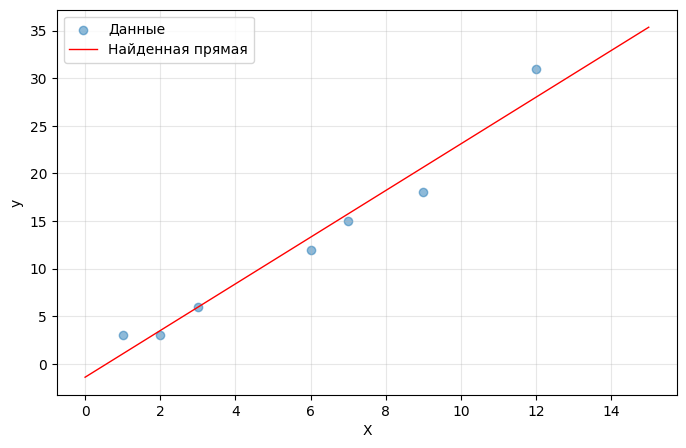

In [ ]:
points = [(1, 3),(2, 3),(3, 6),(6, 12), (7, 15), (9, 18), (12, 31)]
X, y = zip(*points)
X = np.array(X)
y = np.array(y)
model = GeneticRegression()
model.fit(X, y)

print("\nРезультат:")
print(f'best b: {model.best_b}')
print(f'best k: {model.best_k}')

plt.figure(figsize=(8, 5))
plt.scatter(X,y,alpha=0.5,label='Данные')
x_line = np.array([[0], [15]])
y_line = model.best_k * x_line + model.best_b
plt.plot(x_line, y_line, 'r-', linewidth=1, label="Найденная прямая")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()